In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from itertools import product
from dbnomics import fetch_series
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from scipy.stats import chi2
from scipy.stats import t
from scipy.stats import norm
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

In [140]:
# Harmonized Japan CPI
df1 = fetch_series('IMF/CPI/M.JP.PCPI_IX')
df1.to_csv('data.csv')

In [141]:
df1 = pd.read_csv('data.csv', index_col='period')
japanCPI = df1['value']
japanCPI.index = pd.to_datetime(japanCPI.index)
japanCPI = japanCPI.dropna()


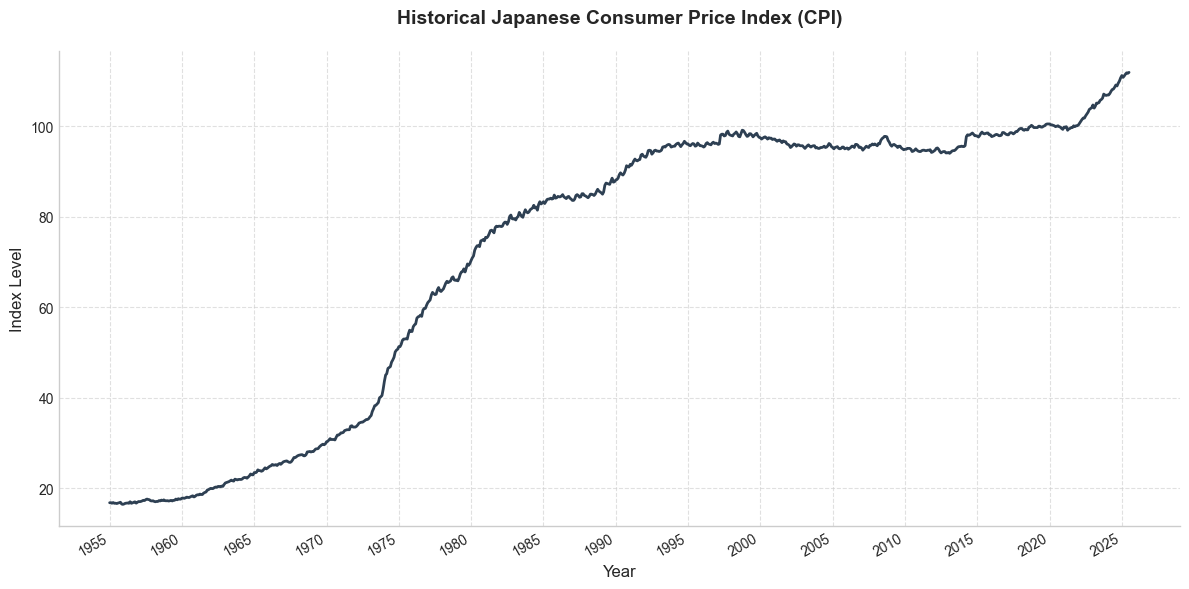

In [142]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(japanCPI.index, japanCPI, color='#2E4053', linewidth=2, label='Japan CPI')
ax.xaxis.set_major_locator(mdates.YearLocator(5)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

ax.set_title('Historical Japanese Consumer Price Index (CPI)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Index Level', fontsize=12)
ax.set_xlabel('Year', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [143]:
def run_adf_test(series, name):
    print(f"--- ADF Test Results for: {name} ---")
    
    # We test the 4 most common forms:
    # 'n'  : No constant, no trend
    # 'c'  : Constant only (default)
    # 'ct' : Constant and trend
    # 'ctt' : Constant and quadratic trend

    
    for regression_type in ['n', 'c', 'ct', 'ctt']:
        result = adfuller(series.dropna(), regression=regression_type, autolag='BIC')
        
        print(f"\nForm: {regression_type}")
        print(f'ADF Statistic: {result[0]:.4f}')
        print(f'p-value: {result[1]:.4f}')
        print('Critical Values:')
        for key, value in result[4].items():
            print(f'\t{key}: {value:.4f}')

run_adf_test(japanCPI, "Japan CPI")

--- ADF Test Results for: Japan CPI ---

Form: n
ADF Statistic: 1.2701
p-value: 0.9477
Critical Values:
	1%: -2.5684
	5%: -1.9413
	10%: -1.6165

Form: c
ADF Statistic: -1.3937
p-value: 0.5853
Critical Values:
	1%: -3.4382
	5%: -2.8650
	10%: -2.5686

Form: ct
ADF Statistic: -1.6634
p-value: 0.7666
Critical Values:
	1%: -3.9697
	5%: -3.4158
	10%: -3.1302

Form: ctt
ADF Statistic: -2.1804
p-value: 0.7393
Critical Values:
	1%: -4.3851
	5%: -3.8395
	10%: -3.5577


The ADF test performed highlights that we don't reject the null for Ho. We've used the 4 main deterministic forms no constants, constants, constant and trend, constant and quadratic trend.

As a result, we can say that the serie is non stationarity, and the source is stochastic, not deterministic.  
We will have to difference the serie.

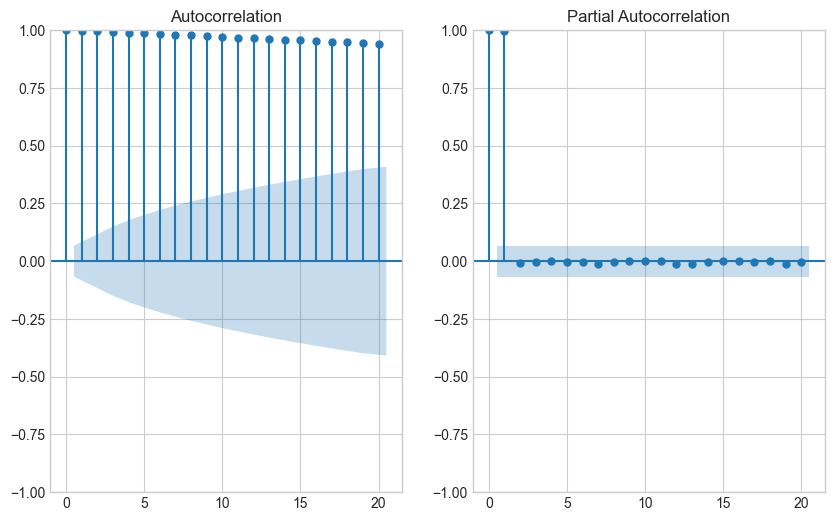

In [144]:
lag = 20
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(japanCPI, lags=lag, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(japanCPI, lags=lag, ax=ax2, alpha=0.05)

Just as a complementary visual approach, the ACF of the raw time serie exhibits a very slow decaying behavior, characteristic of non stationarry series.

We will now difference the serie and analyse whether the new serie is stationarry or there are other issues such as seasonality.

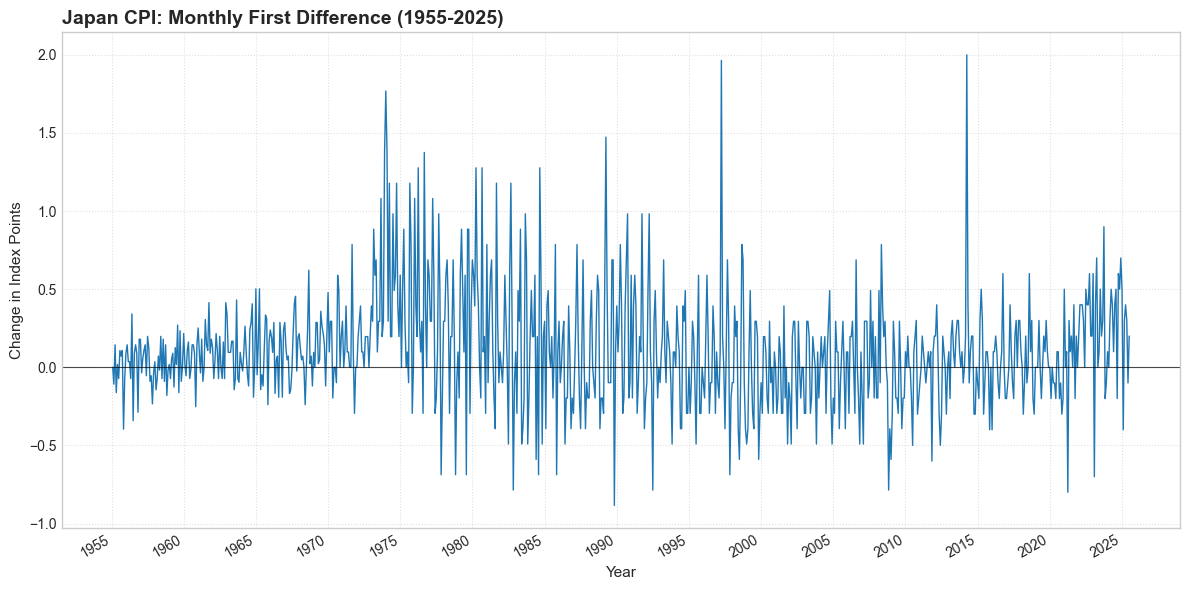

In [145]:
japanCPI_diff = japanCPI.diff()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(japanCPI_diff.index, japanCPI_diff, color='#1F77B4', linewidth=1, label='Monthly Change')
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

ax.xaxis.set_major_locator(mdates.YearLocator(5)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate() 

# 6. Add Titles and Labels
ax.set_title('Japan CPI: Monthly First Difference (1955-2025)', fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel('Change in Index Points', fontsize=11)
ax.set_xlabel('Year', fontsize=11)

ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [146]:
run_adf_test(japanCPI_diff, "Japan CPI")

--- ADF Test Results for: Japan CPI ---

Form: n
ADF Statistic: -2.3779
p-value: 0.0168
Critical Values:
	1%: -2.5684
	5%: -1.9413
	10%: -1.6165

Form: c
ADF Statistic: -3.1697
p-value: 0.0218
Critical Values:
	1%: -3.4382
	5%: -2.8650
	10%: -2.5686

Form: ct
ADF Statistic: -3.2634
p-value: 0.0725
Critical Values:
	1%: -3.9697
	5%: -3.4158
	10%: -3.1302

Form: ctt
ADF Statistic: -3.1870
p-value: 0.2142
Critical Values:
	1%: -4.3851
	5%: -3.8395
	10%: -3.5577


We can see that we reject the test for the case without constant (pure AR), and the test with constant. 
However, it seems the linear and quadratic trends are not rejected.

This is probably an overfitting of the test, as we are working with a differenced time serie.  
Very rare that it exhibits linear or quadratic trend. Graphically also we don't identify such trend.

In [147]:
lag = 5
results = sm.stats.diagnostic.acorr_ljungbox(japanCPI_diff[1:], lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')
    


Lag: 5
LjungBox Statistic:      lb_stat     lb_pvalue
1  35.981625  1.991871e-09
2  41.366154  1.041008e-09
3  41.397592  5.385046e-09
4  50.752115  2.514943e-10
5  85.292196  6.537350e-17


We've performed the LjungBox test until lag 20, and everytime the pvalue is lower than 5%, meaning we reject the null. 

The time serie is not a White Noise, there definetly is autocorrelation to model, and we will use ARMA framework to do so.

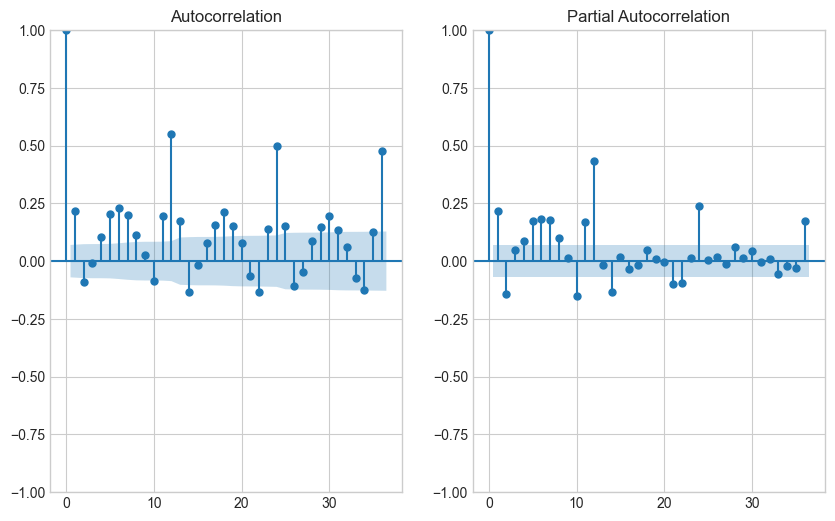

In [148]:
japanCPI_diff = japanCPI_diff.dropna()
end_date ='2019-12-01'

# In Sample Model
japanCPI_diff_in_sample = japanCPI_diff.loc[:end_date]
japanCPI_in_sample = japanCPI.loc[:end_date]

lag = 36
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(japanCPI_diff_in_sample, lags=lag, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(japanCPI_diff_in_sample, lags=lag, ax=ax2, alpha=0.05)

Analysing the ACF and PACF of the differenced time serie for the "in sample part", we can directly identify a lot of spikes, with the biggest ones at lag 12, 24, 36 which suggets a strong seasonality. Additionally, the ACF exhibits a very slow decay for these lags 12, 24 36.  
We might have seasonal unit root, leading to the need of seasonal differencing.  

Before moving to the blind estimation of several models, we will try to verify whether the double differencing (non-seasonal and seasonal is relevant and justified).

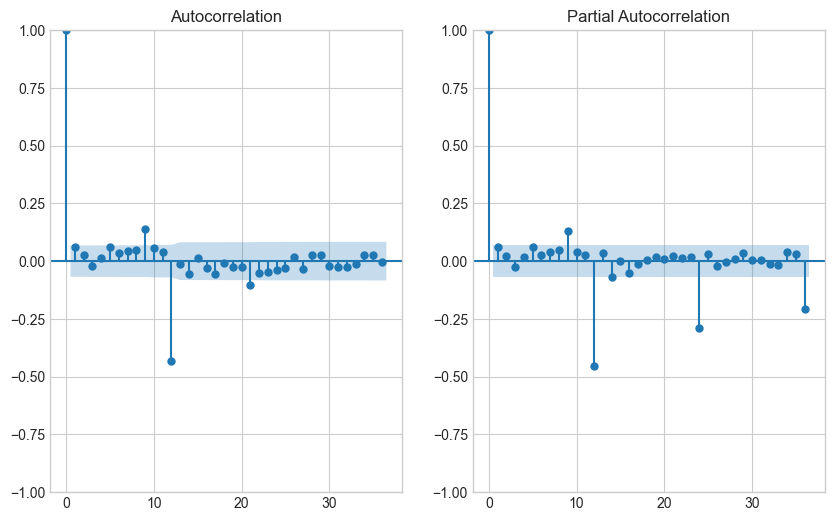

In [149]:
japanCPI_double_diff = japanCPI.diff().diff(12).dropna()

lag = 36
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(japanCPI_double_diff, lags=lag, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(japanCPI_double_diff, lags=lag, ax=ax2, alpha=0.05)


We see that applying both the non-seasonal and the seasonal differencing allows to capture the slow decay of the terms in lag 12, 24, 36, thus correcting for seasonal unit root. We now have only 1 big spike for 12 months, which shows that there is still seasonalitity, but a simple seasonal MA component could be able to capture it.

## Models estimation

We will try several models for p and q orders between 0 and 4.
Additionally, on the seasonal part, we will try first to use a $(0,1,0)_{12}$ component to capture the seasonality.   








In [ ]:
ar_order = range(0, 3) 
ma_order = range(0, 3)

arma_res = []

for p, q in product(ar_order, ma_order):
    try:
        model = sm.tsa.SARIMAX(
            japanCPI, 
            order=(p, 1, q), 
            seasonal_order=(0, 1, 1, 12), 
            enforce_stationarity=False, 
            enforce_invertibility=False,
        ).fit(disp=False)
        
        arma_res.append([p, q, model.aic, model.bic])
    except Exception as e:
        arma_res.append([p, q, np.nan, np.nan])

res = pd.DataFrame(arma_res, columns=['p', 'q', 'AIC', 'BIC'])

print(res.to_string(index=False))

 p  q        AIC        BIC
 0  0 287.954716 297.375763
 0  1 274.564194 288.692107
 0  2 273.596657 292.428993
 1  0 271.984269 286.115839
 1  1 238.874810 257.712027
 1  2 241.097812 264.638232
 2  0 270.654753 289.496846
 2  1 275.684614 299.231136
 2  2 240.853400 269.101904


In [151]:
# 1. On calcule le rang pour chaque critère (1 = le meilleur)
res['rank_AIC'] = res['AIC'].rank(ascending=True)
res['rank_BIC'] = res['BIC'].rank(ascending=True)

# 2. On additionne les rangs
res['Combined_Rank'] = res['rank_AIC'] + res['rank_BIC']

# 3. On trie par le rang combiné le plus petit
res_sorted = res.sort_values('Combined_Rank').reset_index(drop=True)

#print(res_sorted[['p', 'q', 'Q_seas', 'AIC', 'BIC', 'Combined_Rank']].head(10).to_string(index=False))
print(res_sorted[['p', 'q', 'AIC', 'BIC', 'Combined_Rank']].head(10).to_string(index=False))

 p  q        AIC        BIC  Combined_Rank
 1  1 238.874810 257.712027            2.0
 1  2 241.097812 264.638232            5.0
 2  2 240.853400 269.101904            5.0
 1  0 271.984269 286.115839            9.0
 2  0 270.654753 289.496846           10.0
 0  1 274.564194 288.692107           12.0
 0  2 273.596657 292.428993           13.0
 0  0 287.954716 297.375763           17.0
 2  1 275.684614 299.231136           17.0


The model that has the lower coupled values for AIC and BIC is the SARIMA(1,1,1)(0,1,1).  
We will therefore retain this model and try to see if he passes the validation steps.


In [152]:
model1 = sm.tsa.SARIMAX(
            japanCPI_diff_in_sample, 
            order=(1, 1, 1), 
            seasonal_order=(0, 1, 1, 12),
            enforce_stationarity=False, 
            enforce_invertibility=False,
        ).fit(disp=False)

print(model1.summary())



                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  779
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -101.037
Date:                            Sat, 20 Dec 2025   AIC                            210.074
Time:                                    11:22:53   BIC                            228.565
Sample:                                02-01-1955   HQIC                           217.198
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0521      0.033      1.567      0.117      -0.013       0.117
ma.L1         -0.9328      0.012   

We can note that the AR coefficient is slightly not statistically significant.  
It seems that most of the behavior of this time serie is explained by the seasonal MA(12) and the cimple MA components that are very significant.

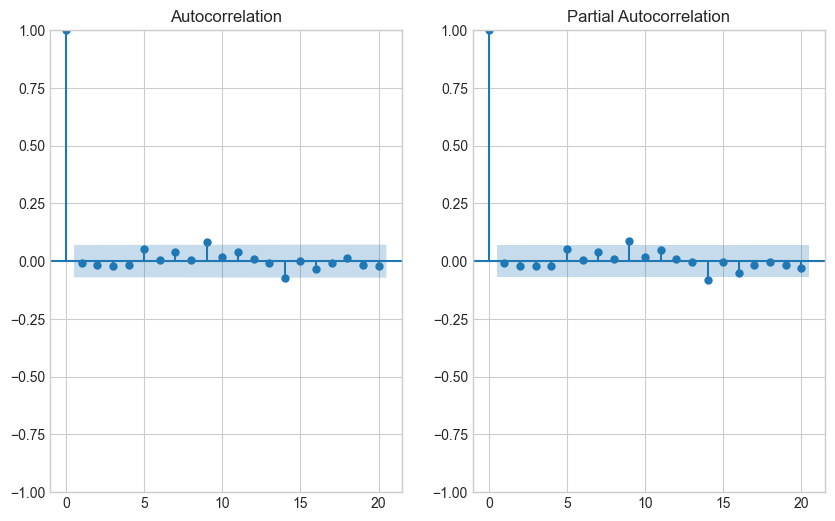

In [153]:
# Validation
residuals = model1.resid

fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(residuals, lags=20, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(residuals, lags=20, ax=ax2, alpha=0.05)

Graphically, we can see that the residuals have an ACF and PACF which is close to a White Noise.  
We have some values at lag 9 and 14 which are very close to the confidence interval, and that we may reject, but reality is never perfect.   
We will test this statistically now.

In [154]:
lb_in = sm.stats.diagnostic.acorr_ljungbox(residuals, lags=[15])
jb_in = sm.stats.stattools.jarque_bera(residuals, axis=0)
print(f'''Ljung Box Test p-value : {lb_in['lb_pvalue']}''')
print('\n')
print(f'Jarque Bera p-value : {jb_in[1]}')

Ljung Box Test p-value : 15    0.393214
Name: lb_pvalue, dtype: float64


Jarque Bera p-value : 4.7745948174577816e-119


Here we can see statistically that we don't reject the Ljung Box test, meaning we don't have remaining autocorelation in the residuals, which is a good thing in terms of specification and validity of our model.  
However, the residuals are clearly not normally distributed.

In order to finalise the specification analysis and test for homoskedasticity, we will test the presence of Arch effet using Ljung Box test on squared reiduals.

In [155]:
arch_effect_in = sm.stats.diagnostic.acorr_ljungbox(residuals**2, lags=[15])
print(arch_effect_in)

      lb_stat  lb_pvalue
15  26.840152   0.030066


We clearly see that we have an Arch effet in our residuals, as the null hypothesis of homoskedasticity is rejected.  
There is heteroskedaticity, which is coherent as we're  working with CPI data which are base on financial market data where variance is not constant trhough time.  
We will therefore use the Garch framework to model it.


In [156]:
orders = [(1, 0), (1, 1), (0,1)]
garch_results = []

for p, q in orders:
    try:
        # mean='Zero' because previous model SARIMA will be used to treat the mean
        model = arch_model(residuals, vol='GARCH', p=p, q=q, mean='Zero', dist='normal')
        res = model.fit(disp='off')
        
        garch_results.append({
            'Order (GARCH p, ARCH q)': f'({p},{q})',
            'AIC': res.aic,
            'BIC': res.bic,
            'Log-Likelihood': res.loglikelihood
        })
    except Exception as e:
        print(f"Erreur pour l'ordre ({p},{q}): {e}")

# Création du tableau comparatif
df_garch = pd.DataFrame(garch_results)
print(df_garch)

Erreur pour l'ordre (0,1): One of p or o must be strictly positive
  Order (GARCH p, ARCH q)         AIC         BIC  Log-Likelihood
0                   (1,0)  166.394205  175.710227      -81.197103
1                   (1,1)  139.097561  153.071594      -66.548781


By comparing both AIC and BIC for the two models, we can see that Garch(1,1) performs better, as we have lower AIC and BIC.

In [157]:
model2 = arch_model(residuals, p=1, o=0, q=1, mean='Zero', dist='normal').fit(disp='off')
print(model2.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -66.5488
Distribution:                  Normal   AIC:                           139.098
Method:            Maximum Likelihood   BIC:                           153.072
                                        No. Observations:                  779
Date:                Sat, Dec 20 2025   Df Residuals:                      779
Time:                        11:22:54   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      4.3448e-04  3.372e-04      1.289      0.198 

Note that we're not interested in the mean equation here, we've already modelize it before. 
So that is normal to have a R-squared equal to 0. 

The results of the optimization tell us that the Garch effect is very strong, as we have a beta coefficient which is statistically significant. However, the constant and alpha coefficient have p-values close to 10% but higher. Meaning they are not statistically significant.  

However, the BIC and AIC of the model is a lot better than a simple ARCH(1) model tested before, so we will keep the Garch(1,1) form.  
A coefficient that is slightly not significant must not automatically be taken out sometimes.

We will now test for validation of the model.

In [158]:
lag = 15
lb_garch_in = sm.stats.diagnostic.acorr_ljungbox(model2.std_resid, lags=[lag])
jb_garch_in = sm.stats.stattools.jarque_bera(model2.std_resid, axis=0)

lb_garch_sq_in = sm.stats.diagnostic.acorr_ljungbox(model2.std_resid**2, lags=[lag])


print(f'''Ljung Box Test on residuals - p-value : {lb_garch_in['lb_pvalue']}''')
print(f'Jarque Bera on residuals - p-value : {jb_garch_in[1]}')
print(f'''Ljung Box Test on squared residuals - p-value : {lb_garch_sq_in['lb_pvalue']}''')

Ljung Box Test on residuals - p-value : 15    0.40136
Name: lb_pvalue, dtype: float64
Jarque Bera on residuals - p-value : 5.7805677406728934e-291
Ljung Box Test on squared residuals - p-value : 15    0.978832
Name: lb_pvalue, dtype: float64


As a result, we can see that the LjungBox test on the residuals is not rejected as before, but additionally, we've been able to correct for homoskedasticity through the use of Garch model for the volatility of our time serie as the LjungBox test on squared residuals is not rejected anymore (p-val=0.89)

To Conclude we retain the following model : $SARIMA(1,1,1)(0,1,1)_{12}-GARCH(1,1)$

# Recursive Forecast

In [ ]:
out_of_sample_indices = japanCPI['2020-01-01':'2025-07-01'].index
forecasts = []
actuals = []
lower_bounds = []
upper_bounds = []

for i, current_date in enumerate(out_of_sample_indices):
    train_data = japanCPI[:current_date].iloc[:-1] 
    actual_val = japanCPI.loc[current_date]
    
    try:
        sarima_model = sm.tsa.SARIMAX(
            train_data,
            order=(1, 1, 1), 
            seasonal_order=(0, 1, 1, 12), 
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        
        # This forecast is directly in level of CPI
        sarima_forecast = sarima_model.get_forecast(steps=1).predicted_mean.iloc[0]
        
        resids = sarima_model.resid.dropna()
        garch_model = arch_model(resids, vol='Garch', p=1, q=1, mean='Zero', dist='normal')
        garch_fit = garch_model.fit(disp='off')

        # 1-step ahead conditional variance from GARCH
        sigma2_forecast = garch_fit.forecast(horizon=1).variance.values[-1, 0]
        sigma_forecast = np.sqrt(sigma2_forecast)

        # Construct 95% prediction interval
        lower = sarima_forecast - 1.96 * sigma_forecast
        upper = sarima_forecast + 1.96 * sigma_forecast

        forecasts.append(sarima_forecast)
        actuals.append(actual_val)
        lower_bounds.append(lower)
        upper_bounds.append(upper)
        
    except Exception as e:
        print(f"Error at {current_date}: {e}")
        forecasts.append(np.nan)
        actuals.append(actual_val)
        lower_bounds.append(np.nan)
        upper_bounds.append(np.nan)

results_df = pd.DataFrame({
    'Actual_Level': actuals,
    'Level_Forecast': forecasts,
    'Lower_95': lower_bounds,
    'Upper_95': upper_bounds,
}, index=out_of_sample_indices)

results_df['Error'] = results_df['Actual_Level'] - results_df['Level_Forecast']

# Comparision

In [171]:
rmse = np.sqrt(mean_squared_error(results_df['Actual_Level'], results_df['Level_Forecast']))
mae = mean_absolute_error(results_df['Actual_Level'], results_df['Level_Forecast'])

print(f"Out-of-Sample RMSE: {rmse:.4f}")
print(f"Out-of-Sample MAE: {mae:.4f}")

Out-of-Sample RMSE: 0.3195
Out-of-Sample MAE: 0.2436


The root mean square error is only 0.3438 index points. On a base of 100, this is an excellent performance for a period characterized by a significant inflationary regime shift.

The Mean Absolute Error is close to the RMSE, proving the absence of "large errors" or unmanaged outliers. The model successfully adapted to the structural transition from deflation to inflation that occurred in 2022.

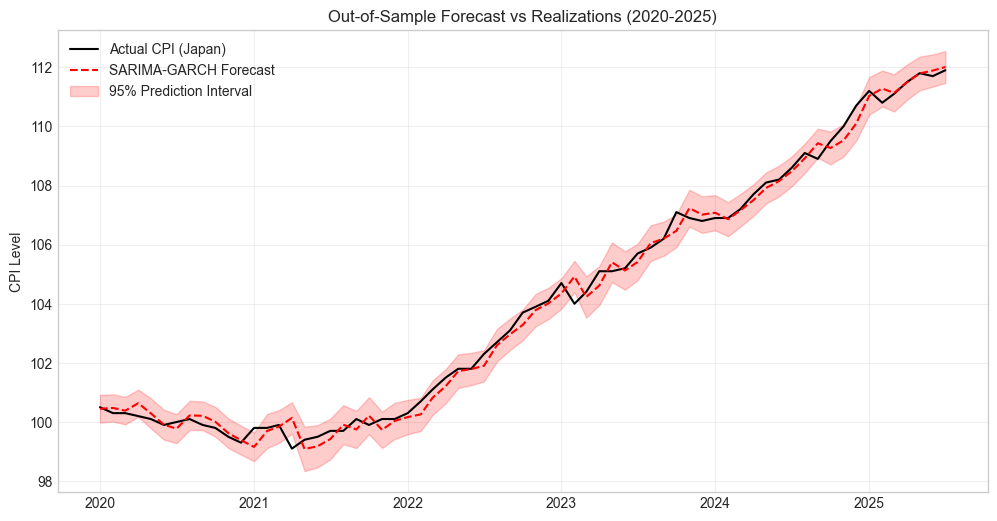

In [172]:
plt.figure(figsize=(12,6))
plt.plot(results_df['Actual_Level'], label='Actual CPI (Japan)', color='black', linewidth=1.5)
plt.plot(results_df['Level_Forecast'], label='SARIMA-GARCH Forecast', color='red', linestyle='--')

plt.fill_between(
    results_df.index,
    results_df['Lower_95'],
    results_df['Upper_95'],
    color='red',
    alpha=0.2,
    label='95% Prediction Interval'
)

plt.title('Out-of-Sample Forecast vs Realizations (2020-2025)')
plt.ylabel('CPI Level')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The 1-step-ahead SARIMA(1,1,1)(0,1,1,12) + GARCH(1,1) model produces highly accurate out-of-sample forecasts for Japanese CPI from 2020 to 2025. The point forecasts closely track actual CPI levels, with minimal deviations.  

The 95% GARCH-based prediction intervals effectively capture most variations in volatility, demonstrating that the model not only predicts the mean accurately but also provides reliable measures of forecast uncertainty. Indeed, we only have 2 points outside the band (begining of 2021 and 2023)